<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_007_aprendizaje_supervisado/_006_03_KNN_Cuatro_Categorias_interactivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KNN con cuatro categorías y distancia euclidiana
KNN conserva los datos de entrenamiento y clasifica por votación entre los K vecinos más próximos. K es un hiperparámetro. Este ejemplo utiliza dos características (estatura y peso) y cuatro clases simuladas, identificadas como 1, 2, 3 y 4. No se atribuye un significado demográfico a cada clase.

Se conservan los centros, la dispersión, la semilla y los votos uniformes del ejemplo original.


Text(0, 0.5, 'Peso en kilogramos')

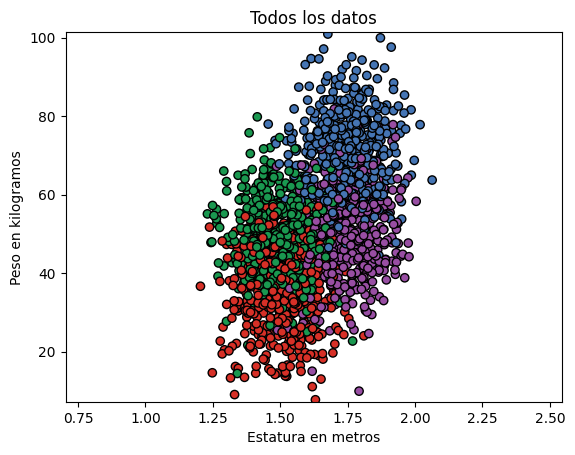

In [1]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

X, y = make_blobs(n_samples=[500,500,500,500],
                  n_features = 2,
                  centers=[[1.50,35],[1.75,70],[1.50,50],[1.75,50]],
                  cluster_std = [[0.1,10],[0.1,10],[0.1,10],[0.1,10]],
                  random_state=1970)
y = y + 1
colores = ["#d73027", "#4575b4", "#1a9850", "#984ea3"]
cm_clases = ListedColormap(colores)
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

# just plot the dataset first
cm = cm_clases
cm_bright = cm
#cm_bright = ListedColormap(['#FF0000', '#0000FF','#0FF000', '#000000'])
ax = plt.figure()
plt.title("Todos los datos")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright,
            edgecolors='k')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel("Estatura en metros")
plt.ylabel("Peso en kilogramos")


Son cuatro grupos sintéticos de 500 muestras, descritos por dos características. Cuatro categorías no significa cuatro características.


Dado que las escalas de peso y estaturas son muy diferentes
(dos ordenes de magnitud)
Antes de aplicar el clasificador, debemos llevarlas
a la misma escala:
* Se resta la media
* Se divide por la desviación estándar


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_original = X.copy()
X_train_original, X_test_original, y_train, y_test = train_test_split(
    X_original, y, test_size=0.33, random_state=1970, stratify=y)
escalador = StandardScaler()
X_train = escalador.fit_transform(X_train_original)
X_test = escalador.transform(X_test_original)
X = escalador.transform(X_original)
X_estandarizada = X


Y volvemos a mostrar los datos ...

Text(0, 0.5, 'Peso estandarizado')

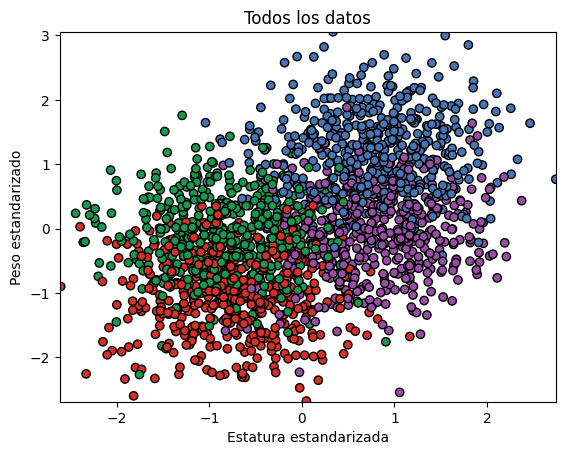

In [3]:
x_min, x_max = X[:, 0].min() - .01, X[:, 0].max() + .01
y_min, y_max = X[:, 1].min() - .01, X[:, 1].max() + .01
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

# just plot the dataset first
#cm = plt.cm.RdBu
#cm_bright = ListedColormap(['#FF0000', '#0000FF','#0FF000', '#000000'])
ax = plt.figure()
plt.title("Todos los datos")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright,
            edgecolors='k')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel("Estatura estandarizada")
plt.ylabel("Peso estandarizado")


Separamos antes de estandarizar. La media y la desviación se calculan solo con entrenamiento; las clases se mantienen balanceadas mediante separación estratificada.


In [4]:
print(f'Entrenamiento: {len(y_train)}; prueba: {len(y_test)}')


Entrenamiento: 1340; prueba: 660


In [5]:
from sklearn import neighbors
clfKNN = neighbors.KNeighborsClassifier(n_neighbors=101, # número de vecinos
                                        weights='uniform', # pesos asignados a los vecinos al momento
                                                           # de tomar la decisión
                                                           # 'uniform', 'distance'
                                        algorithm='brute', # optimiza la ejecución del clasificador
                                                           # ‘auto’, ‘ball_tree’, ‘kd_tree’, ‘brute’
                                        p=2, # usado para la fórmula de la distancia de Minkowski
                                        metric='minkowski')
clfKNN.fit(X_train,y_train)
y_esperado = y_test
y_predicho = clfKNN.predict(X_test)

In [6]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_esperado,y_predicho))

0.7272727272727273


El accuracy anterior corresponde al K inicial de 101. El desempeño debe medirse, no suponerse superior al 90 %, especialmente cuando las cuatro clases se solapan.


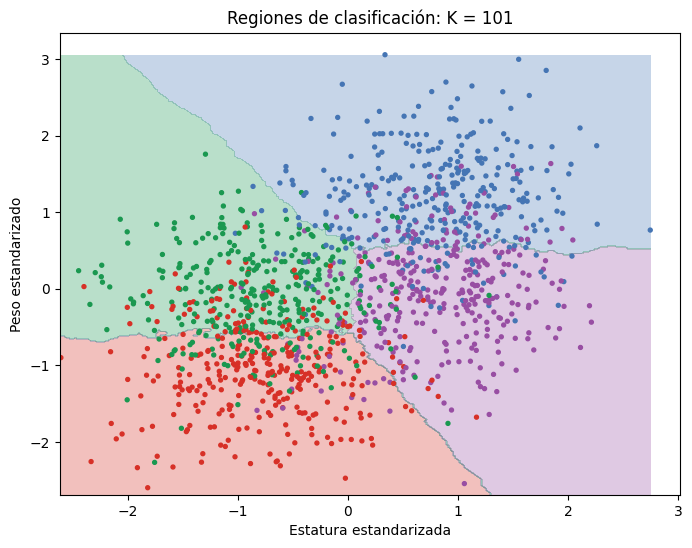

In [7]:
# En multiclase se elige la clase de mayor probabilidad, sin umbral 0.5.
Z = clfKNN.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, levels=np.arange(.5, 5, 1), cmap=cm_clases, alpha=.3)
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_clases,
           vmin=1, vmax=4, s=8)
ax.set(xlabel='Estatura estandarizada', ylabel='Peso estandarizado',
       title='Regiones de clasificación: K = 101')
plt.show()


Y esto es lo que el sistema sabe

## 1. Métricas frente a K: validación cruzada
Se exploran K = 5, 10, …, 200 en cinco particiones estratificadas del entrenamiento. La estandarización se ajusta dentro de cada partición. La prueba se reserva para la evaluación final, sin usarla para seleccionar K.

- **Accuracy, F1 macro, ROC-AUC y Kappa:** mayor es mejor. F1 macro da igual peso a cada clase; ROC-AUC se calcula uno contra el resto (OvR), con promedio macro. Kappa no usa ponderaciones ordinales.
- **Log loss y Brier:** menor es mejor. Se utilizan todas las probabilidades de las cuatro clases.
- Brier multiclase se define aquí como $B=\frac{1}{N}\sum_i\sum_{c=1}^{4}(p_{ic}-\mathbf{1}[y_i=c])^2$. Su rango es 0 a 2: **no se divide entre clases ni entre dos**. En binario esta convención vale el doble de la usada en el cuaderno anterior.

Las bandas representan media ± una desviación estándar entre particiones, no intervalos de confianza. Las escalas verticales son automáticas: diferencias visuales grandes pueden corresponder a mejoras numéricas pequeñas.


Mejores medias de validación (menor K en empates exactos):
Accuracy            : K=165, media=0.738060
F1 macro            : K=165, media=0.738433
ROC-AUC macro OvR   : K=130, media=0.927230
Kappa               : K=165, media=0.650746
Log loss            : K=130, media=0.646037
Brier multiclase    : K= 50, media=0.369203


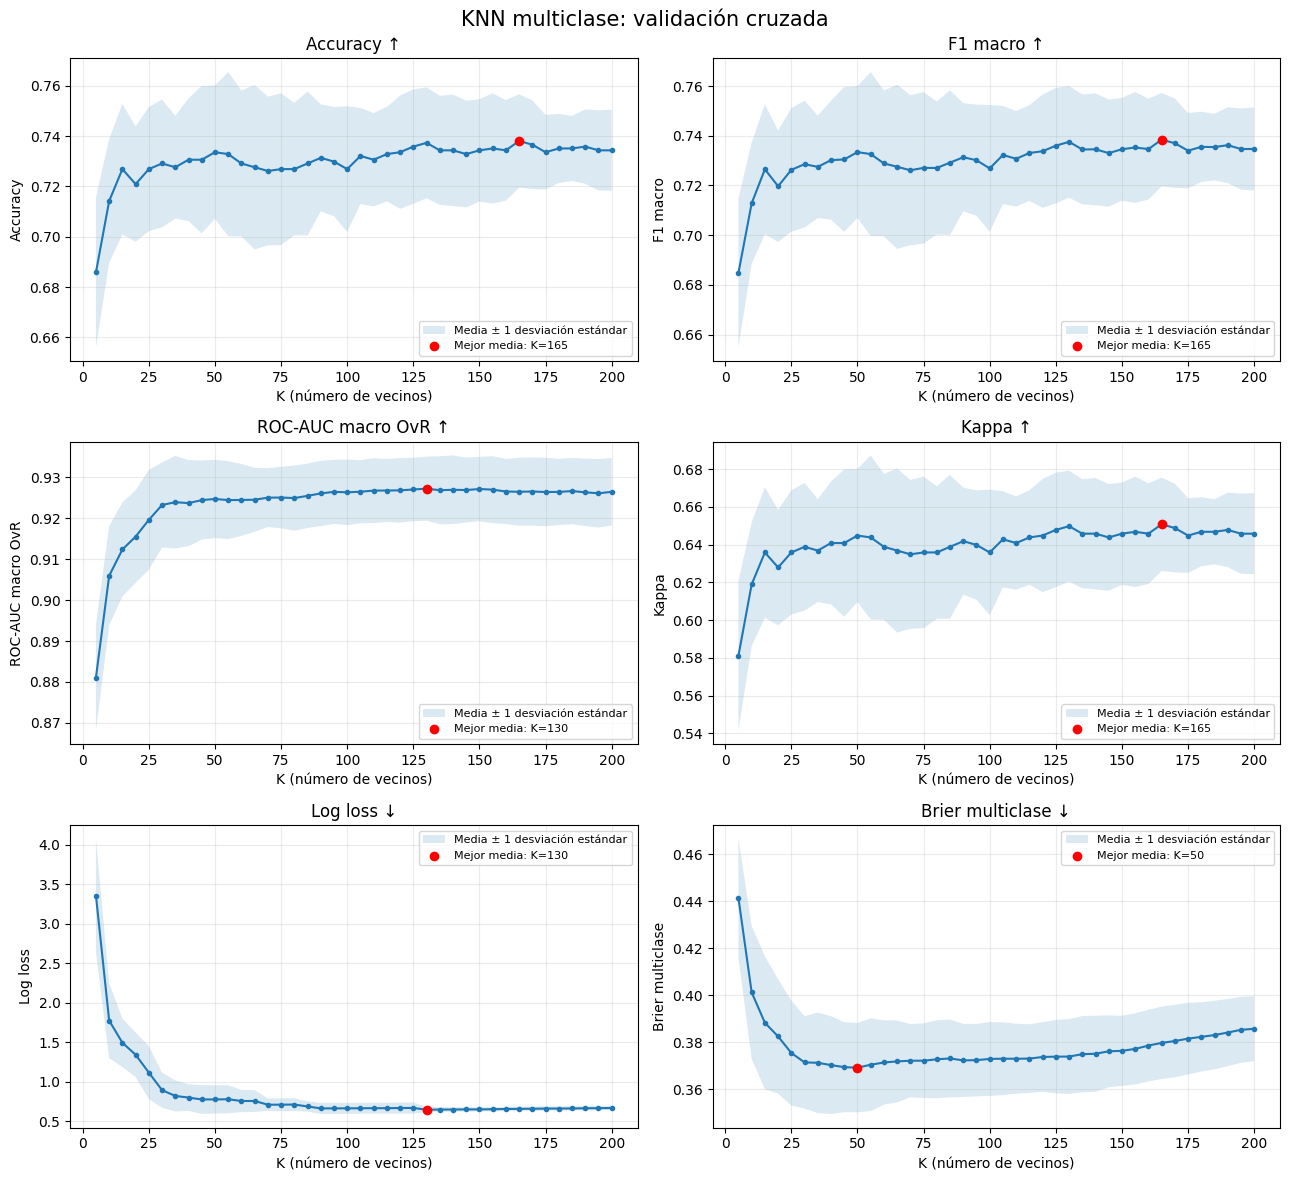

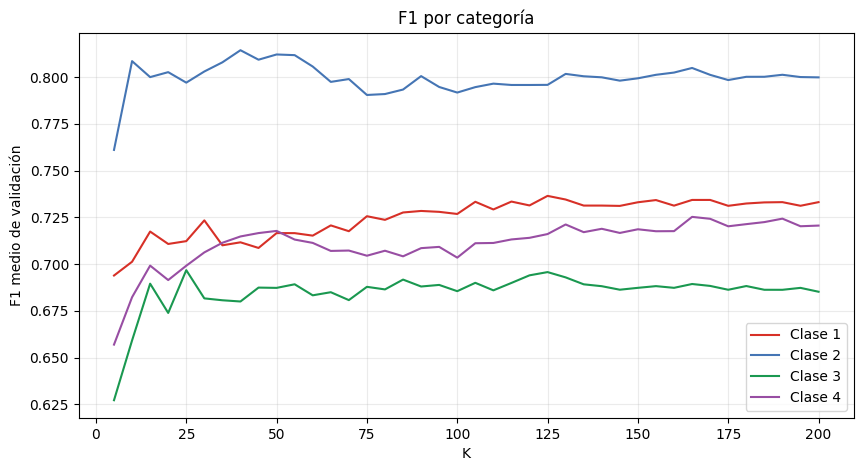

In [8]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             cohen_kappa_score, log_loss)

valores_k = np.arange(5, 201, 5)
particiones = list(StratifiedKFold(n_splits=5, shuffle=True,
                                 random_state=1970).split(X_train_original, y_train))
if max(valores_k) > min(len(it) for it, _ in particiones):
    raise ValueError('No hay suficientes ejemplos de entrenamiento para K=200 en cada fold.')
nombres_metricas = ['Accuracy', 'F1 macro', 'ROC-AUC macro OvR', 'Kappa', 'Log loss', 'Brier multiclase']
resultados = {nombre: np.zeros((len(valores_k), 5)) for nombre in nombres_metricas}
f1_clases = np.zeros((len(valores_k), 5, 4))
clases = np.unique(y_train)

for fold, (it, iv) in enumerate(particiones):
    scaler = StandardScaler()
    xt = scaler.fit_transform(X_train_original[it])
    xv = scaler.transform(X_train_original[iv])
    yt, yv = y_train[it], y_train[iv]
    for j, k in enumerate(valores_k):
        modelo = clone(clfKNN).set_params(n_neighbors=int(k)).fit(xt, yt)
        proba = modelo.predict_proba(xv)
        pred = modelo.classes_[np.argmax(proba, axis=1)]
        real_onehot = (yv[:, None] == modelo.classes_[None, :]).astype(float)
        valores = [accuracy_score(yv, pred),
                   f1_score(yv, pred, average='macro', zero_division=0),
                   roc_auc_score(yv, proba, multi_class='ovr', average='macro', labels=modelo.classes_),
                   cohen_kappa_score(yv, pred),
                   log_loss(yv, proba, labels=modelo.classes_),
                   np.mean(np.sum((proba-real_onehot)**2, axis=1))]
        for nombre, valor in zip(nombres_metricas, valores):
            resultados[nombre][j, fold] = valor
        f1_clases[j, fold] = f1_score(yv, pred, labels=clases, average=None, zero_division=0)

fig, axes = plt.subplots(3, 2, figsize=(13, 12), sharex=True)
print('Mejores medias de validación (menor K en empates exactos):')
for ax, nombre in zip(axes.ravel(), nombres_metricas):
    media = resultados[nombre].mean(axis=1)
    sd = resultados[nombre].std(axis=1, ddof=1)
    minimizar = nombre in ['Log loss', 'Brier multiclase']
    indice = np.argmin(media) if minimizar else np.argmax(media)
    ax.plot(valores_k, media, 'o-', markersize=3)
    ax.fill_between(valores_k, media-sd, media+sd, alpha=.16,
                    label='Media ± 1 desviación estándar')
    ax.scatter(valores_k[indice], media[indice], color='red', zorder=5,
               label=f'Mejor media: K={valores_k[indice]}')
    ax.set(title=nombre + (' ↓' if minimizar else ' ↑'),
           xlabel='K (número de vecinos)', ylabel=nombre)
    ax.tick_params(labelbottom=True)
    ax.ticklabel_format(axis='y', style='plain', useOffset=False)
    ax.grid(alpha=.25)
    ax.legend(fontsize=8)
    print(f'{nombre:20s}: K={valores_k[indice]:3d}, media={media[indice]:.6f}')
fig.suptitle('KNN multiclase: validación cruzada', fontsize=15)
fig.tight_layout()
plt.show()

# El promedio macro puede ocultar diferencias entre clases.
fig, ax = plt.subplots(figsize=(10, 5))
for c, clase in enumerate(clases):
    ax.plot(valores_k, f1_clases[:, :, c].mean(axis=1), color=colores[c],
            label=f'Clase {clase}')
ax.set(xlabel='K', ylabel='F1 medio de validación', title='F1 por categoría')
ax.grid(alpha=.25)
ax.legend()
plt.show()


## 2. Regiones interactivas con un deslizador para K
K cambia de 5 a 200, de uno en uno. El fondo representa la clase predicha y los puntos representan las clases reales de entrenamiento. Se mantienen fijos los ejes y los colores. Esta exploración no utiliza la prueba para elegir K.

La categoría predicha es la de mayor probabilidad; ninguna necesita superar 0.5 para resultar elegida. En empates, scikit-learn elige la primera clase según su orden.

Ejecute las celdas en orden con un kernel activo. Si falta `ipywidgets`, ejecute `%pip install ipywidgets`. En Colab se habilita el gestor de widgets automáticamente. La figura se actualiza al soltar el deslizador.


In [9]:
import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Patch
from functools import lru_cache
try:
    from google.colab import output as salida_colab
except ImportError:
    pass
else:
    salida_colab.enable_custom_widget_manager()

gx = np.linspace(X_train[:, 0].min()-.3, X_train[:, 0].max()+.3, 140)
gy = np.linspace(X_train[:, 1].min()-.3, X_train[:, 1].max()+.3, 140)
mx, my = np.meshgrid(gx, gy)
consultas = np.c_[mx.ravel(), my.ravel()]

@lru_cache(maxsize=196)
def regiones_k(k):
    modelo = clone(clfKNN).set_params(n_neighbors=int(k)).fit(X_train, y_train)
    return modelo.predict(consultas).reshape(mx.shape)

def mostrar_k(k):
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.contourf(mx, my, regiones_k(k), levels=np.arange(.5, 5, 1),
                cmap=cm_clases, alpha=.3)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
               cmap=cm_clases, vmin=1, vmax=4, s=12,
               edgecolors='white', linewidths=.2)
    ax.set(title=f'KNN: cuatro categorías | K = {k} | votos uniformes',
           xlabel='Estatura estandarizada', ylabel='Peso estandarizado',
           xlim=(gx[0], gx[-1]), ylim=(gy[0], gy[-1]))
    ax.legend(handles=[Patch(color=color, label=f'Clase {clase}')
                       for clase, color in zip(clases, colores)])
    fig.tight_layout()
    plt.show()
    plt.close(fig)

barra_k = widgets.IntSlider(value=101, min=5, max=200, step=1,
                            description='K:', continuous_update=False,
                            layout=widgets.Layout(width='650px'))
salida = widgets.interactive_output(mostrar_k, {'k': barra_k})
display(widgets.VBox([barra_k, salida]))


## Interpretación
Seleccione el criterio según su objetivo: F1 macro para dar igual importancia a las clases, Log loss/Brier para calidad de probabilidades. Examine también el F1 por categoría. Los mejores K pueden diferir entre métricas; una zona estable puede ser más convincente que una diferencia mínima entre medias. Una vez fijado K, ajuste sobre todo el entrenamiento y evalúe sobre la prueba reservada.
